# Leveraging Data Mining to Understand and Predict Airbnb Listing Prices

An end-to-end workflow that includes:

1.  **Setup & Data Loading:** Import libraries and load our two raw data files.
2.  **Data Merging & Cleaning:** Combine the 2020 and 2023 datasets, handling the column mismatch. We will also perform our key cleaning steps, like handling missing data and outliers.
3.  **Feature Engineering:** Create our new, insightful features: `price_category` and the spatial-economic `neighbourhood_tier`.
4.  **Preprocessing:** Prepare the data for our models (One-Hot Encoding, Scaling, and Log Transformation).
5.  **Model Training & Evaluation:** Train our baseline `LinearRegression` model and the more advanced `RandomForestRegressor` to compare their performance.

## 1. Setup & Data Loading

In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import kagglehub
import os

# Preprocessing Tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Settings
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Path to the dataset
path = kagglehub.dataset_download("kritikseth/us-airbnb-open-data")

#Connecting to files in path
csv_path1 = os.path.join(path, "AB_US_2020.csv")
csv_path2 = os.path.join(path, "AB_US_2023.csv")
#Load the data from CSV files
df1 = pd.read_csv(csv_path1)
df2 = pd.read_csv(csv_path2)
#Previewing the two datasets
print(df1.describe())
print(df2.describe())

100%|██████████| 22.9M/22.9M [00:00<00:00, 66.5MB/s]

Extracting files...


                 id       host_id       latitude      longitude  \
count  2.260300e+05  2.260300e+05  226030.000000  226030.000000   
mean   2.547176e+07  9.352385e+07      35.662829    -103.220662   
std    1.317814e+07  9.827422e+07       6.849855      26.222091   
min    1.090000e+02  2.300000e+01      18.920990    -159.714900   
25%    1.515890e+07  1.399275e+07      32.761783    -118.598115   
50%    2.590916e+07  5.138266e+07      37.261125     -97.817200   
75%    3.772624e+07  1.497179e+08      40.724038     -76.919323   
max    4.556085e+07  3.679176e+08      47.734620     -70.995950   

               price  minimum_nights  number_of_reviews  reviews_per_month  \
count  226030.000000    2.260300e+05      226030.000000       177428.00000   
mean      219.716529    4.525490e+02          34.506530            1.43145   
std       570.353609    2.103376e+05          63.602914            1.68321   
min         0.000000    1.000000e+00           0.000000            0.01000   
25%   

## 2. Data Merging & Cleaning

The two files can't be combined directly because they don't have the same columns. We will solve this by finding the set of columns they share.

In [ ]:
#checking the length of columns in df1 and df2
print(f'Columns in df1 = {len(df1.columns)}')
print(f'Columns in df2 = {len(df2.columns)}')

#Selecting columns common in both df1 and df2 before concatenating the dataframes
df1_cols = set(df1.columns)
df2_cols = set(df2.columns)

#Common columns
common = df1_cols & df2_cols
unique_to_df2 = df2_cols - df1_cols
print("Common columns:", common)
print("Columns unique to df2:", unique_to_df2)

Columns in df1 = 17
Columns in df2 = 18
Common columns: {'reviews_per_month', 'calculated_host_listings_count', 'longitude', 'host_id', 'neighbourhood', 'id', 'price', 'last_review', 'city', 'name', 'room_type', 'host_name', 'neighbourhood_group', 'availability_365', 'minimum_nights', 'number_of_reviews', 'latitude'}
Columns unique to df2: {'number_of_reviews_ltm'}


In [ ]:
# Finding unique columns in df1 (columns that are in df1 but not in df2)
unique_df1 = df1_cols - df2_cols
print("\nColumns unique to df1:", unique_df1)
# Finding unique columns in df2 (columns that are in df2 but not in df1)
unique_df2 = df2_cols - df1_cols
print("\nColumns unique to df2:", unique_df2)


#selecting only common columns in df2 to merge df1.
df2 = df2[list(common)]
len(df2.columns)

#concatenating df1 and df2
joined_df = pd.concat([df1, df2], axis=0, ignore_index=True)
merged_df = joined_df.copy()

joined_df.head()
joined_df.shape


Columns unique to df1: set()

Columns unique to df2: {'number_of_reviews_ltm'}


(458177, 17)

### 2.1. Handling Missing Data

Now we'll apply the cleaning logic from our report. We'll drop `neighbourhood_group` (too many missing) and any rows with other missing values.

In [ ]:
print("Missing values BEFORE cleaning:")
print(joined_df.isnull().sum())

# Drop 'neighbourhood_group' as it's over 50% missing
if 'neighbourhood_group' in joined_df.columns:
    joined_df = joined_df.drop(columns=['neighbourhood_group'])

# Drop rows with other missing values (e.g., 'last_review', 'reviews_per_month')
joined_df = joined_df.dropna()

print("\nShape AFTER dropping missing data:", joined_df.shape)
print("\nMissing values AFTER cleaning:")
print(joined_df.isnull().sum().sum()) # Should be 0

Missing values BEFORE cleaning:
id                                     0
name                                  44
host_id                                0
host_name                             46
neighbourhood_group               251492
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                                  0
minimum_nights                         0
number_of_reviews                      0
last_review                        97687
reviews_per_month                  97687
calculated_host_listings_count         0
availability_365                       0
city                                   0
dtype: int64

Shape AFTER dropping missing data: (360444, 16)

Missing values AFTER cleaning:
0


### 2.2. Handling Outliers

This is the second key challenge from our report. A Z-score approach didn't work for `price`. We will apply our domain-based filters.

In [ ]:
# 1. Store the "Before" data for comparison
df_before = joined_df.copy()
df_before['status'] = 'Before'

In [ ]:
print(f"Shape BEFORE outlier filtering: {joined_df.shape}")

# 2. Price Outlier Handling
# Apply a domain-based filter of $10 to $700
joined_df = joined_df[(joined_df['price'] >= 10) & (joined_df['price'] <= 700)]

# Also apply filters for other numeric features
joined_df = joined_df[(joined_df['minimum_nights'] >= 1) & (joined_df['minimum_nights'] <= 14)]

# For these, we can use a Z-score as they are less skewed
for col in ['availability_365', 'calculated_host_listings_count']:
    if col in joined_df.columns:
        joined_df[f'{col}_z'] = zscore(joined_df[col])
        joined_df = joined_df[np.abs(joined_df[f'{col}_z']) <= 2]
        joined_df = joined_df.drop(columns=[f'{col}_z'])

print(f"Shape AFTER outlier filtering: {joined_df.shape}")

Shape BEFORE outlier filtering: (360444, 16)
Shape AFTER outlier filtering: (259576, 16)


In [ ]:
# 3. Store the "After" data
df_after = joined_df.copy()
df_after['status'] = 'After'

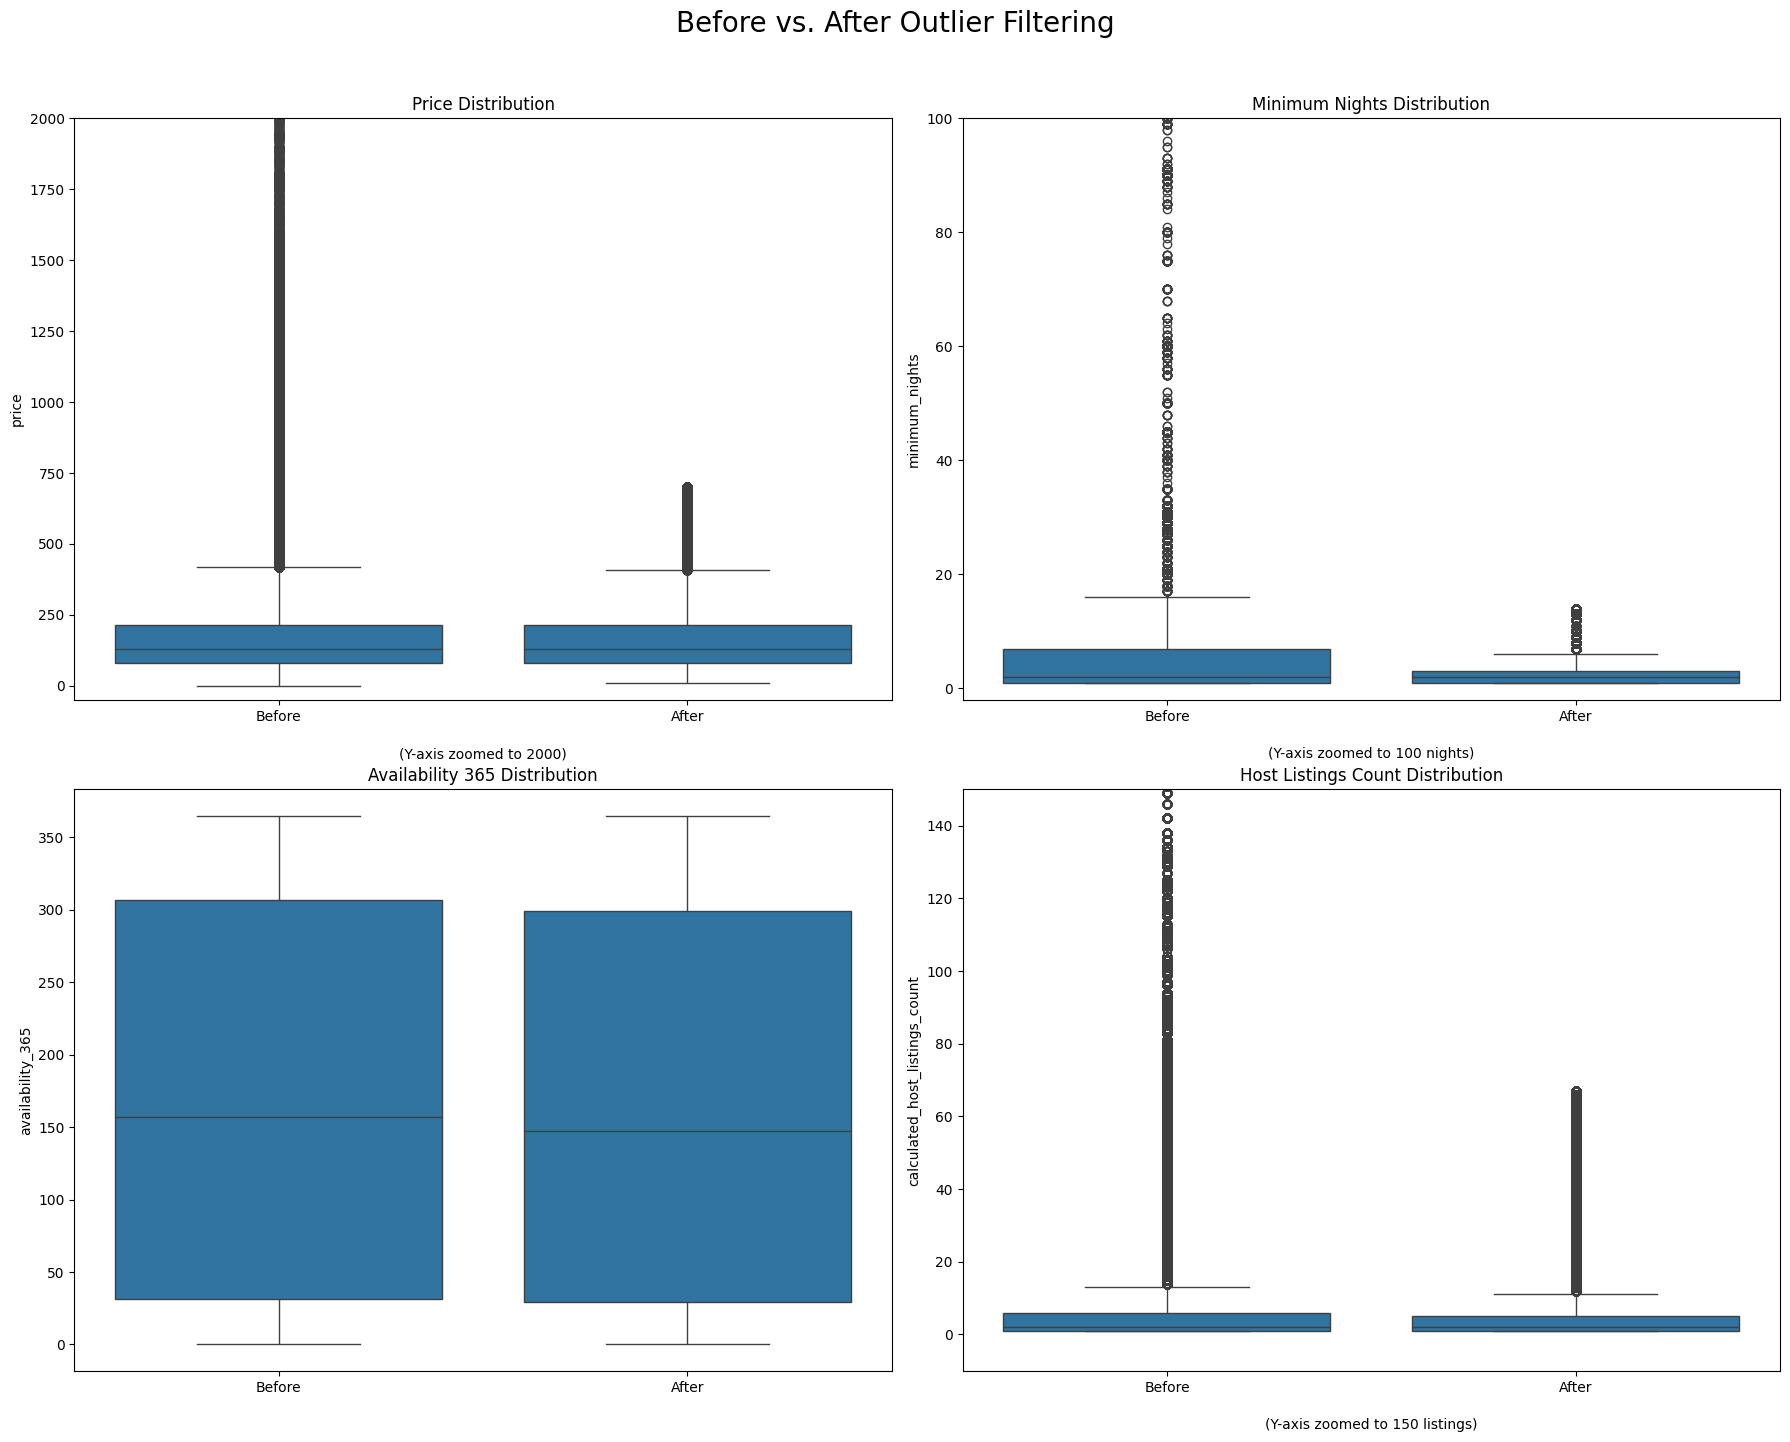

In [ ]:
# 4. Combine the datasets for plotting
cols_to_plot = ['price', 'minimum_nights', 'availability_365', 'calculated_host_listings_count', 'status']
df_plot = pd.concat([df_before[cols_to_plot], df_after[cols_to_plot]])

# 5. Create the 2x2 Visualization Grid
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Before vs. After Outlier Filtering', fontsize=20, y=1.02)
axes = axes.flatten() # Make it easy to loop

# --- Plot 1: Price ---
sns.boxplot(x='status', y='price', data=df_plot, ax=axes[0], order=['Before', 'After'])
axes[0].set_title('Price Distribution')
# We set a Y-limit to make the "After" box visible, otherwise outliers skew the chart
axes[0].set_ylim(-50, 2000)
axes[0].set_xlabel('')
axes[0].text(0.5, -0.1, '(Y-axis zoomed to 2000)',
             horizontalalignment='center', transform=axes[0].transAxes)

# --- Plot 2: Minimum Nights ---
sns.boxplot(x='status', y='minimum_nights', data=df_plot, ax=axes[1], order=['Before', 'After'])
axes[1].set_title('Minimum Nights Distribution')
# Set Y-limit to show detail
axes[1].set_ylim(-2, 100)
axes[1].set_xlabel('')
axes[1].text(0.5, -0.1, '(Y-axis zoomed to 100 nights)',
             horizontalalignment='center', transform=axes[1].transAxes)

# --- Plot 3: Availability 365 ---
sns.boxplot(x='status', y='availability_365', data=df_plot, ax=axes[2], order=['Before', 'After'])
axes[2].set_title('Availability 365 Distribution')
axes[2].set_xlabel('')

# --- Plot 4: Host Listings Count ---
sns.boxplot(x='status', y='calculated_host_listings_count', data=df_plot, ax=axes[3], order=['Before', 'After'])
axes[3].set_title('Host Listings Count Distribution')
# Set Y-limit to show detail
axes[3].set_ylim(-10, 150)
axes[3].set_xlabel('')
axes[3].text(0.5, -0.1, '(Y-axis zoomed to 150 listings)',
             horizontalalignment='center', transform=axes[3].transAxes)

plt.tight_layout()
plt.show()


## 3. Feature Engineering

With a clean dataset, we can now create our new, more powerful features to help the model.

### 3.1. Feature 1: Price Categories

We'll segment the `price` into four categories based on quartiles. This helps with analysis and could be used for a classification model later.

In [ ]:
joined_df['price_category'] = pd.qcut(joined_df['price'],
                                q=4,
                                labels=['Budget', 'Midrange', 'Upscale', 'Luxury'])

print("Price Category distribution:")
print(joined_df['price_category'].value_counts())

Price Category distribution:
price_category
Midrange    66055
Budget      65259
Luxury      64631
Upscale     63631
Name: count, dtype: int64


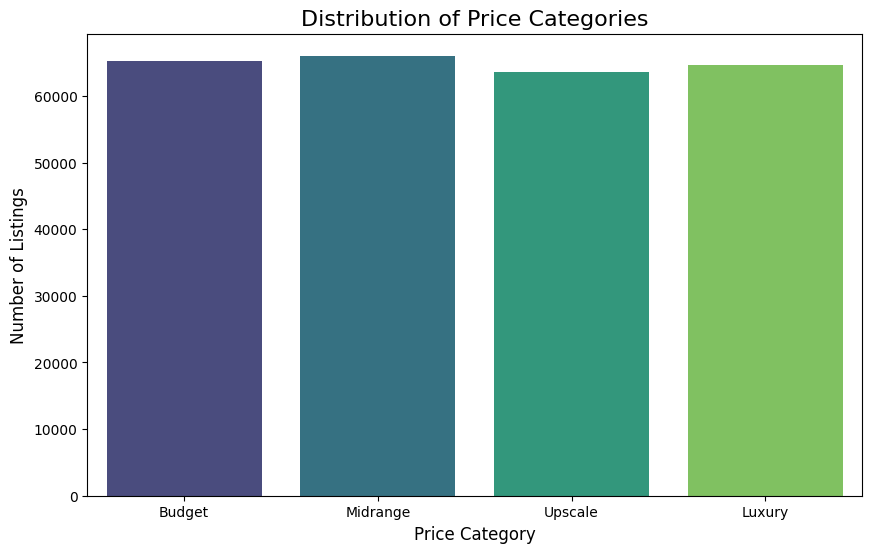

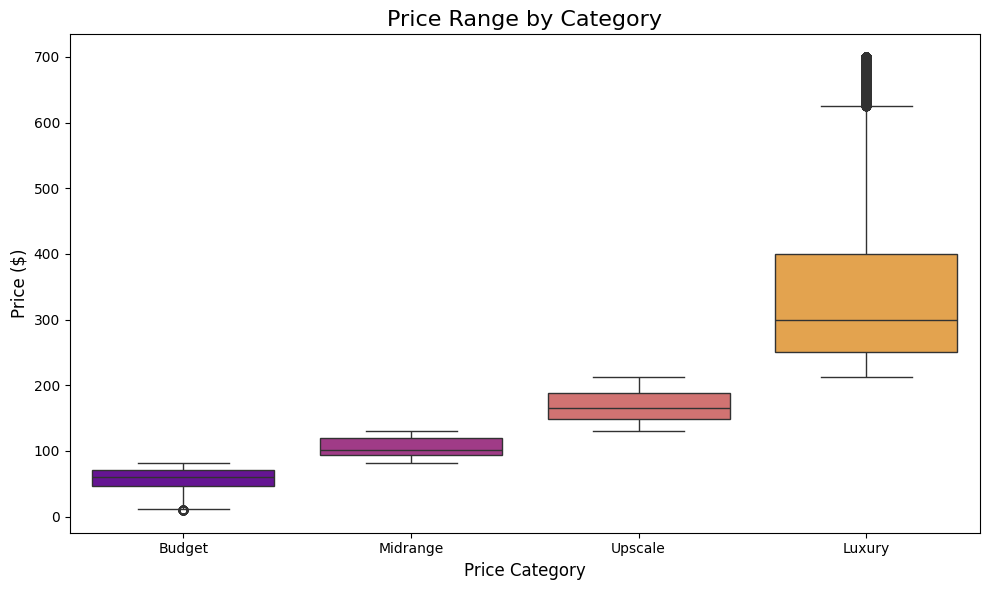

In [ ]:
# Visualization 1: Count Plot (Distribution of Categories)
plt.figure(figsize=(10, 6))
sns.countplot(
    x='price_category',
    data=joined_df,
    order=['Budget', 'Midrange', 'Upscale', 'Luxury'],
    palette='viridis'
)
plt.title('Distribution of Price Categories', fontsize=16)
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

# Visualization 2: Box Plot (Price Ranges for Each Category)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='price_category',
    y='price',
    data=joined_df,
    order=['Budget', 'Midrange', 'Upscale', 'Luxury'],
    palette='plasma'
)
plt.title('Price Range by Category', fontsize=16)
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

### 3.2. Feature 2: Spatial-Economic Tier

This is the more complex feature from our report. We will create a composite score based on distance-to-city-center and price, then cluster listings into tiers.

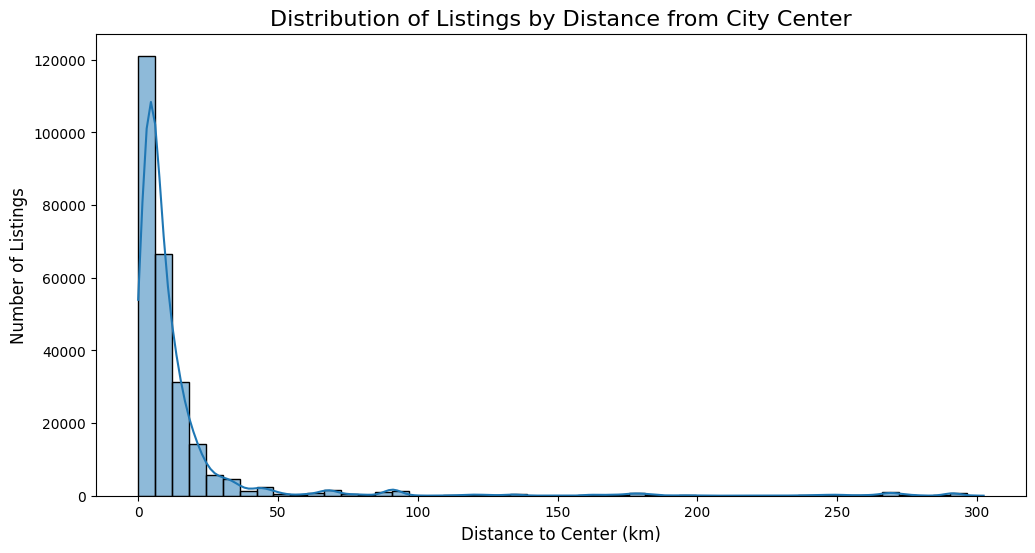

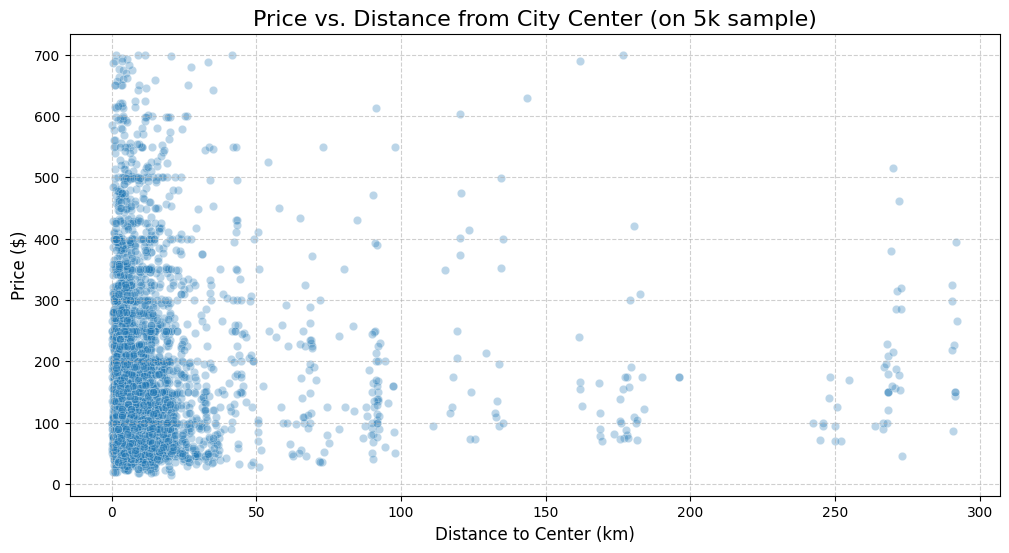

In [ ]:
# 1. Create 'distance_to_center'

# Step 1: Find the geographic center for each city
city_centers = joined_df.groupby('city')[['latitude', 'longitude']].mean().to_dict('index')

# Step 2: Define the calculation functions
def haversine_distance(lat1, lon1, lat2, lon2):
    # function to calculate distance (in km)
    R = 6371 # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

def get_distance_to_center(row):
   center = city_centers[row['city']]
   return haversine_distance(row['latitude'], row['longitude'], center['latitude'], center['longitude'])


# Step 3: Apply the function to create the new column
joined_df['distance_to_center'] = joined_df.apply(get_distance_to_center, axis=1)


# 2. Visualizations for the New Feature

# Plot 1: Histogram (distribution of distances)
plt.figure(figsize=(12, 6))
sns.histplot(joined_df['distance_to_center'], bins=50, kde=True)
plt.title('Distribution of Listings by Distance from City Center', fontsize=16)
plt.xlabel('Distance to Center (km)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.show()


# Plot 2: Scatter Plot (Does distance relate to price?)
# We use a sample to avoid overplotting
df_sample = joined_df.sample(min(5000, len(joined_df)))

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='distance_to_center',
    y='price',
    data=df_sample,
    alpha=0.3
)
plt.title('Price vs. Distance from City Center (on 5k sample)', fontsize=16)
plt.xlabel('Distance to Center (km)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Neighbourhood Tier distribution:
neighbourhood_tier
Midtown                      86526
Central Business District    86526
Downtown                     86524
Name: count, dtype: int64

DataFrame head with new features:
        city  price  distance_to_center  composite_score  \
0  Asheville     60           10.508079        -0.735052   
1  Asheville    470            2.460540         2.818468   
3  Asheville     90            3.405185        -0.287775   
5  Asheville    134            4.782350         0.029161   
6  Asheville     48            3.614238        -0.634105   

          neighbourhood_tier  
0                    Midtown  
1  Central Business District  
3                   Downtown  
5                   Downtown  
6                    Midtown  


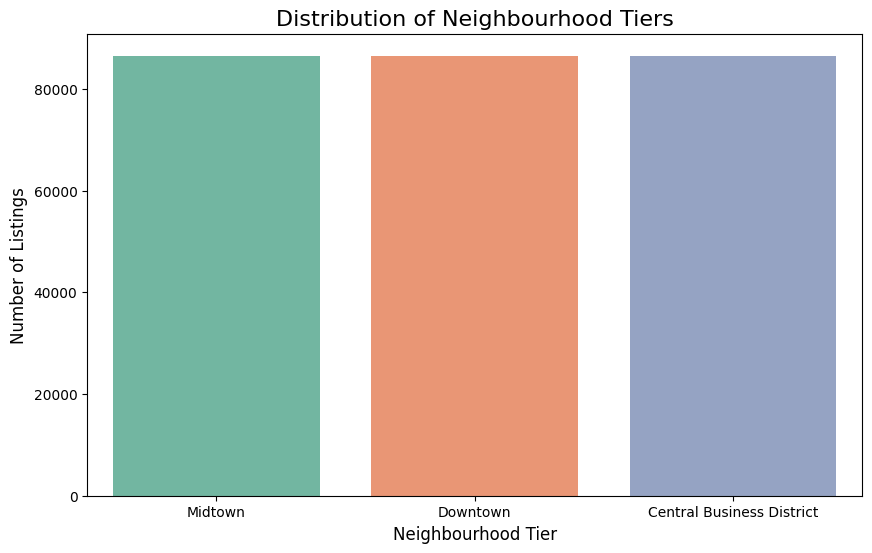

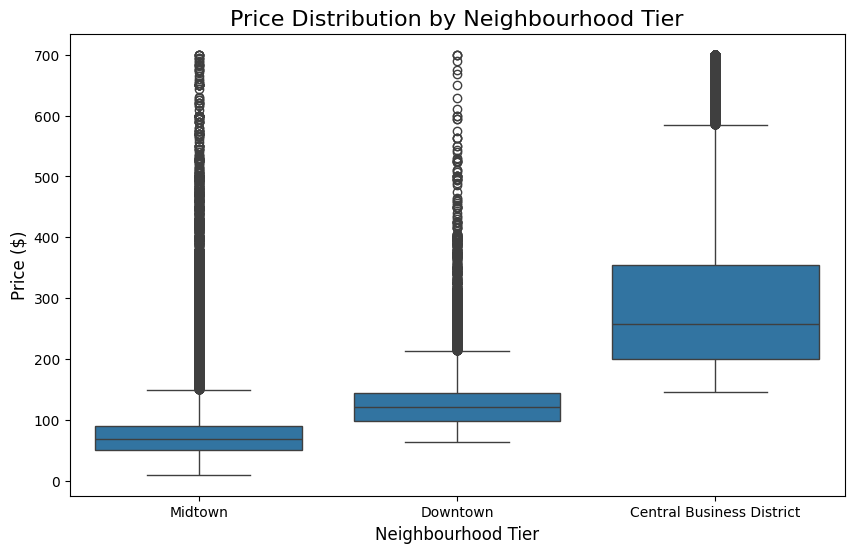

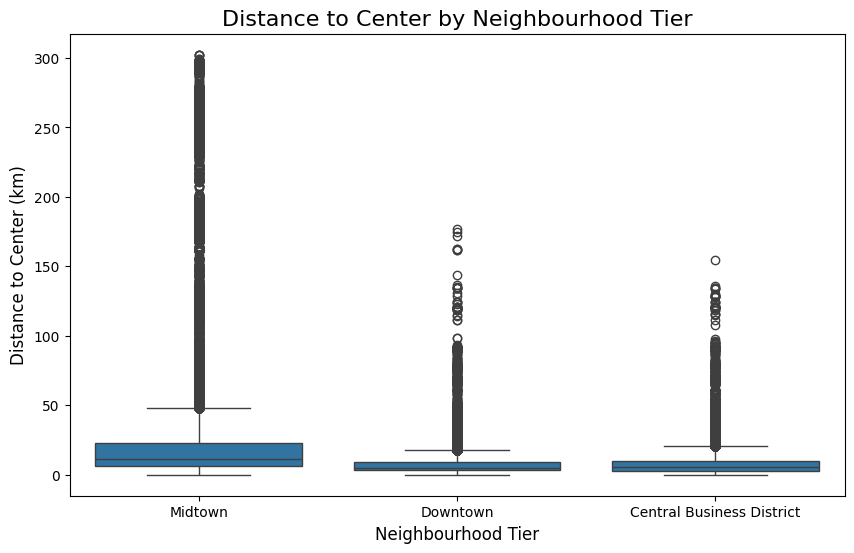

In [ ]:
# Step 4: Normalize distance and price
scaler = StandardScaler()
joined_df['distance_normalized'] = scaler.fit_transform(joined_df[['distance_to_center']])
joined_df['price_normalized'] = scaler.fit_transform(joined_df[['price']])

# Step 5: Create composite score
# High price and low distance (inverted) = high score
joined_df['composite_score'] = joined_df['price_normalized'] - joined_df['distance_normalized']

# Step 6: Group into tiers
tier_labels = ['Midtown', 'Downtown', 'Central Business District']
joined_df['neighbourhood_tier'] = pd.qcut(joined_df['composite_score'],
                                          q=3,
                                          labels=tier_labels,
                                          duplicates='drop')

print("Neighbourhood Tier distribution:")
print(joined_df['neighbourhood_tier'].value_counts())
print("\nDataFrame head with new features:")
print(joined_df[['city', 'price', 'distance_to_center', 'composite_score', 'neighbourhood_tier']].head())


# NEW Visualizations for 'neighbourhood_tier'
# Plot 1: Count Plot (Is the new category balanced?)
plt.figure(figsize=(10, 6))
sns.countplot(
    x='neighbourhood_tier',
    data=joined_df,
    order=tier_labels,
    palette='Set2'
)
plt.title('Distribution of Neighbourhood Tiers', fontsize=16)
plt.xlabel('Neighbourhood Tier', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.show()

# Plot 2: Box Plot (Does our 'tier' relate to 'price'?)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='neighbourhood_tier',
    y='price',
    data=joined_df,
    order=tier_labels
)
plt.title('Price Distribution by Neighbourhood Tier', fontsize=16)
plt.xlabel('Neighbourhood Tier', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()

# Plot 3: Box Plot (Does our 'tier' relate to 'distance'?)
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='neighbourhood_tier',
    y='distance_to_center',
    data=joined_df,
    order=tier_labels
)
plt.title('Distance to Center by Neighbourhood Tier', fontsize=16)
plt.xlabel('Neighbourhood Tier', fontsize=12)
plt.ylabel('Distance to Center (km)', fontsize=12)
plt.show()

## 4. Data Preprocessing for Modeling

Our data is clean and features are engineered. Now we must prepare it for the machine learning models. This involves:
1.  **Defining Features (X) and Target (y):** Our target `y` will be `price`.
2.  **Log Transformation:** As we did in our notebooks, we'll log-transform `price` to handle its skewness, which helps linear models.
3.  **One-Hot Encoding:** Convert categorical features (`room_type`, `city`, `neighbourhood_tier`) into numbers.
4.  **Scaling:** Standardize all numerical features so they are on the same scale.

In [ ]:
# Define Target variable (y)
# We use np.log1p() which is log(1 + x) to handle skewness and any potential 0s
y = np.log1p(joined_df['price'])

# Define Feature matrix (X)
# We drop the target 'price' and any non-feature or intermediate columns
columns_to_drop = [
    'price', 'id', 'name', 'host_id', 'host_name', 'last_review', 'price_category',
    'latitude', 'longitude', 'distance_to_center', 'distance_normalized',
    'price_normalized', 'composite_score', 'neighbourhood'
]

X = joined_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nFeatures (X) head:")
X.head()

Shape of X: (259576, 8)
Shape of y: (259576,)

Features (X) head:


,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,city,neighbourhood_tier
0,Private room,1,138,1.14,1,0,Asheville,Midtown
1,Entire home/apt,1,114,1.03,11,288,Asheville,Central Business District
3,Entire home/apt,1,267,2.39,5,0,Asheville,Downtown
5,Entire home/apt,7,54,0.49,1,294,Asheville,Downtown
6,Private room,1,137,1.35,1,0,Asheville,Midtown


In [ ]:
# Identify categorical and numerical features
categorical_features = ['room_type', 'city', 'neighbourhood_tier']
numerical_features = X.columns.drop(categorical_features).tolist()

print(f"Categorical: {categorical_features}")
print(f"Numerical: {numerical_features}")

# Create the preprocessing pipeline (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

# Apply the preprocessing
X_processed = preprocessor.fit_transform(X)

Categorical: ['room_type', 'city', 'neighbourhood_tier']
Numerical: ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


## 5. Model Training & Evaluation

Now for the final step. We'll split our processed data and train the models as planned.

In [ ]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (207660, 38)
Test set shape: (51916, 38)


### Model 1: Linear Regression (Our Baseline)

This model serves as our baseline to see how well a simple model performs.

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Make predictions
y_pred_lin = lin_model.predict(X_test)

# Evaluate the model
# Note: We must use np.sqrt() on mean_squared_error to get RMSE
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("--- Linear Regression Results ---")
print(f"RMSE (on log-price): {rmse_lin:.4f}")
print(f"R² Score: {r2_lin:.4f}")

--- Linear Regression Results ---
RMSE (on log-price): 0.3180
R² Score: 0.7834


### Model 2: Random Forest Regressor

Now we'll train the more complex model, Random Forest, to see if it can capture more complex patterns and improve performance.

In [ ]:
# We'll use n_jobs=-1 to use all available processors for faster training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Results ---")
print(f"RMSE (on log-price): {rmse_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

--- Random Forest Results ---
RMSE (on log-price): 0.2990
R² Score: 0.8086
